In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel(
    r"C:\Users\kondu\Downloads\GenAI-Knowledge-Assistant-main\ds cs\forecasting-system\data\raw\sales_data.xlsx"
)

# Clean columns
df.columns = df.columns.str.strip().str.lower()

# Rename total -> sales
df.rename(columns={
    'total': 'sales'
}, inplace=True)

# Convert date
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

print(df.head())

        state       date        sales   category
0     Alabama 2019-01-12  109574036.0  Beverages
1     Arizona 2019-01-12  109101594.6  Beverages
2    Arkansas 2019-01-12   58049432.2  Beverages
3  California 2019-01-12  444766890.6  Beverages
4    Colorado 2019-01-12   89816716.3  Beverages


In [6]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   state     8084 non-null   object        
 1   date      8084 non-null   datetime64[ns]
 2   sales     8084 non-null   float64       
 3   category  8084 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 252.8+ KB
None
              sales
count  8.084000e+03
mean   1.658580e+08
std    1.610566e+08
min    9.732839e+06
25%    6.393281e+07
50%    1.171426e+08
75%    2.010132e+08
max    9.853746e+08
state       0
date        0
sales       0
category    0
dtype: int64


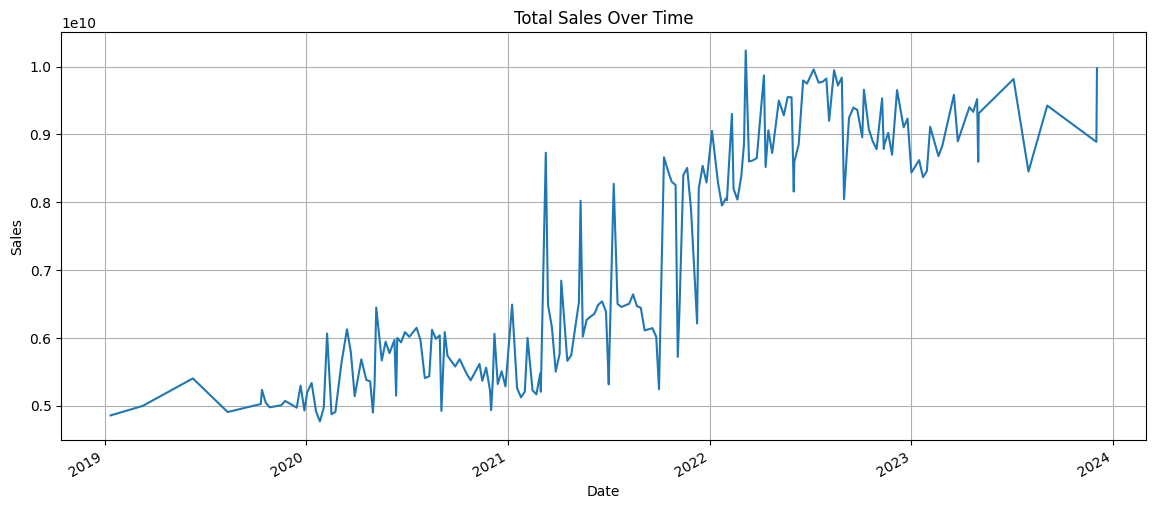

In [7]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(14,6))

daily_sales.plot()

plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

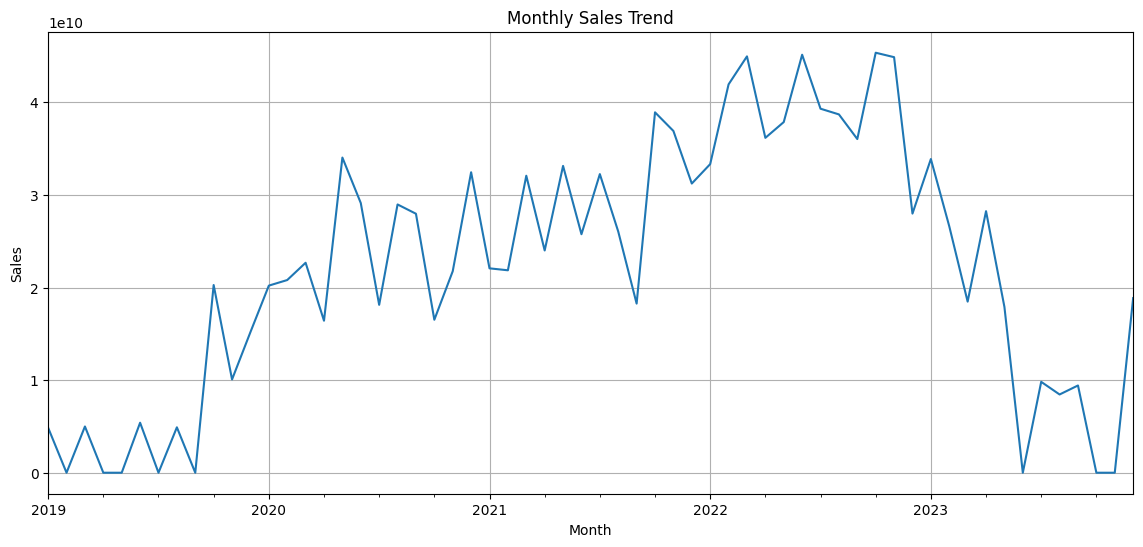

In [8]:
monthly_sales = (
    df.groupby(
        pd.Grouper(key='date', freq='M')
    )['sales']
    .sum()
)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

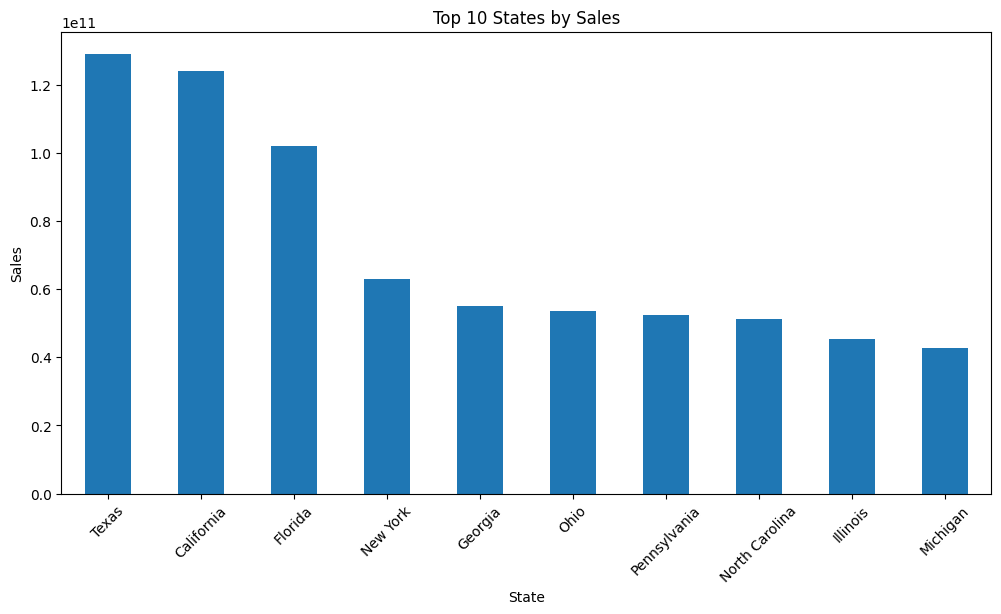

In [9]:
state_sales = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_sales.plot(kind='bar')

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

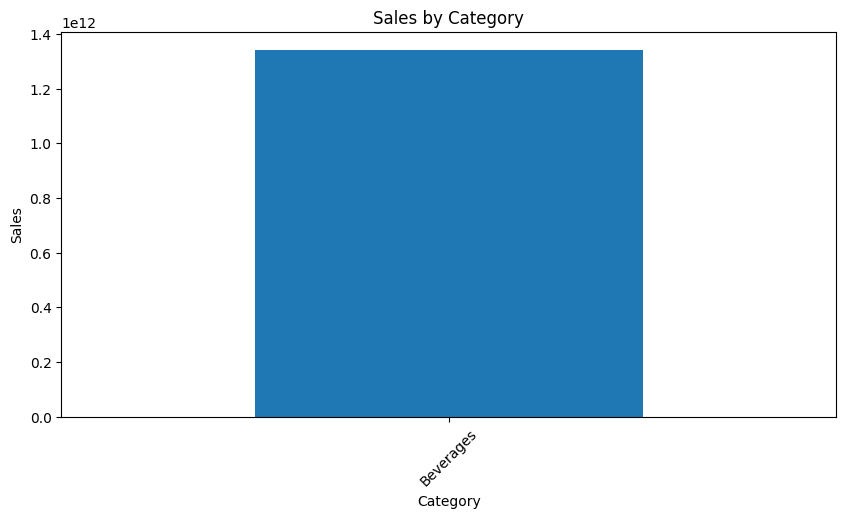

In [10]:
category_sales = (
    df.groupby("category")["sales"]
    .sum()
)

plt.figure(figsize=(10,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

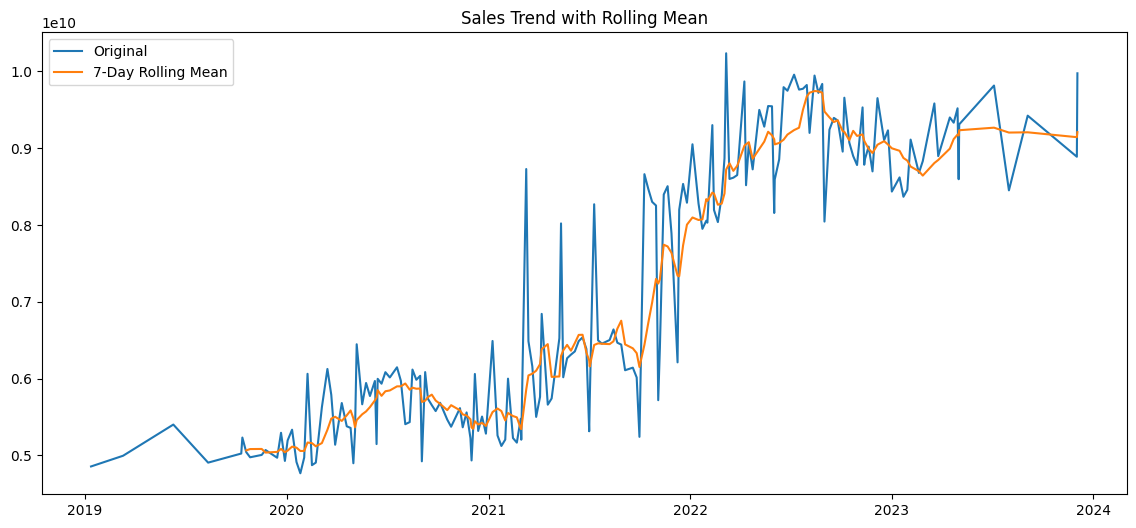

In [11]:
daily_sales = (
    df.groupby("date")["sales"]
    .sum()
)

rolling_mean = daily_sales.rolling(7).mean()

plt.figure(figsize=(14,6))

plt.plot(daily_sales, label='Original')

plt.plot(
    rolling_mean,
    label='7-Day Rolling Mean'
)

plt.legend()

plt.title("Sales Trend with Rolling Mean")

plt.show()

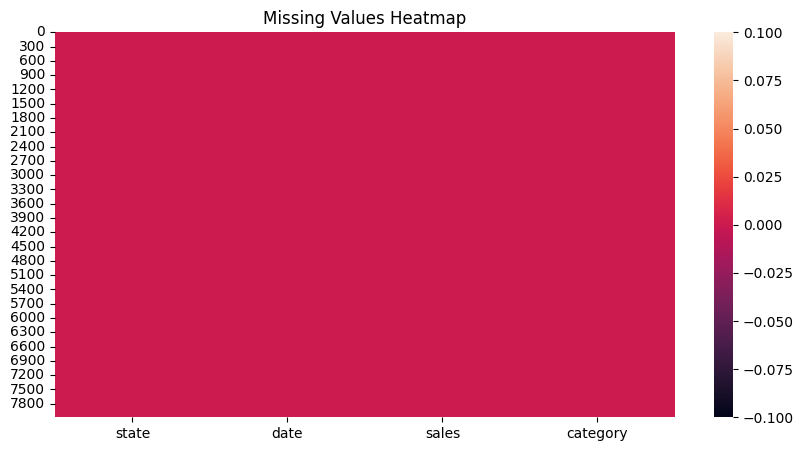

In [12]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.heatmap(df.isnull())

plt.title("Missing Values Heatmap")

plt.show()